## Import librerie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.impute import SimpleImputer

## Caricamento e indicizzazione

In [2]:
df = pd.read_csv("titanic_sub.csv", index_col="PassengerId")
df.head()

,Sex,Age,Pclass,Embarked,Survived
PassengerId,,,,,
1,male,22.0,3,S,0
2,female,38.0,1,C,1
3,female,26.0,3,S,1
4,female,35.0,1,S,1
5,male,35.0,3,S,0


## Esplorazione rapida

In [3]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(891, 5)
Sex          object
Age         float64
Pclass        int64
Embarked     object
Survived      int64
dtype: object
Sex           0
Age         177
Pclass        0
Embarked      2
Survived      0
dtype: int64


## Analisi esplorativa (EDA)

In [4]:
# Sbilanciamento del target
print("Distribuzione classe target:")
print(df["Survived"].value_counts())
print(df["Survived"].value_counts(normalize=True).round(3))

# Distribuzione Age
print("\nDistribuzione Age:")
print(df["Age"].describe())

# Distribuzione Embarked
print("\nDistribuzione Embarked:")
print(df["Embarked"].value_counts())

# Sopravvivenza per Sex
print("\nSopravvivenza per Sex:")
print(df.groupby("Sex")["Survived"].mean().round(3))

# Sopravvivenza per Pclass
print("\nSopravvivenza per Pclass:")
print(df.groupby("Pclass")["Survived"].mean().round(3))

Distribuzione classe target:
Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64

Distribuzione Age:
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

Distribuzione Embarked:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Sopravvivenza per Sex:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

Sopravvivenza per Pclass:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


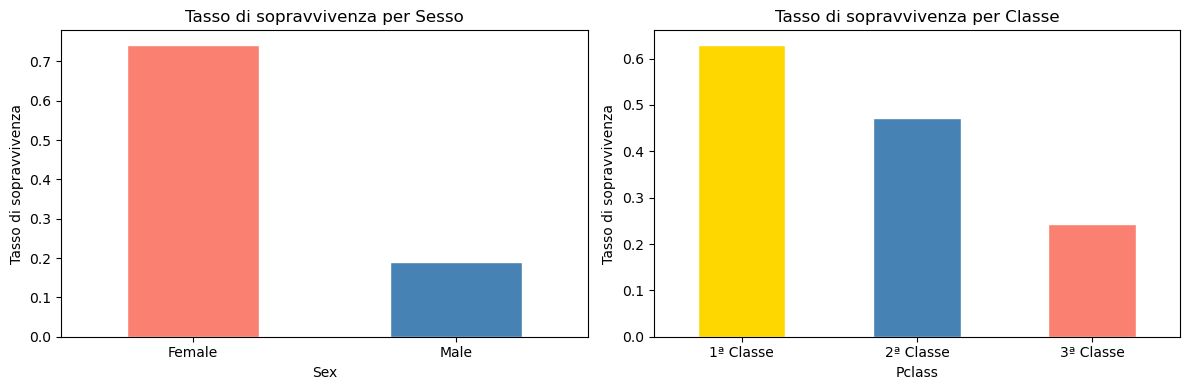

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sopravvivenza per Sex
df.groupby("Sex")["Survived"].mean().plot(
    kind="bar", ax=axes[0], color=["salmon", "steelblue"], edgecolor="white"
)
axes[0].set_title("Tasso di sopravvivenza per Sesso")
axes[0].set_ylabel("Tasso di sopravvivenza")
axes[0].set_xticklabels(["Female", "Male"], rotation=0)

# Sopravvivenza per Pclass
df.groupby("Pclass")["Survived"].mean().plot(
    kind="bar", ax=axes[1], color=["gold", "steelblue", "salmon"], edgecolor="white"
)
axes[1].set_title("Tasso di sopravvivenza per Classe")
axes[1].set_ylabel("Tasso di sopravvivenza")
axes[1].set_xticklabels(["1ª Classe", "2ª Classe", "3ª Classe"], rotation=0)

plt.tight_layout()
plt.show()

L'EDA evidenzia:
- Il dataset è sbilanciato (61.6% non sopravvissuti): l'accuracy da sola 
  non è sufficiente, servono precision e recall.
- Age ha distribuzione abbastanza simmetrica (mediana 28, media 29.7): 
  la mediana è una scelta robusta per l'imputazione.
- Embarked è dominato da S (644 su 891): la moda è la scelta corretta 
  per i 2 valori mancanti.
- Il sesso è la feature più discriminante: le donne sopravvivono al 74.2%, 
  gli uomini al 18.9%.
- La classe di viaggio è fortemente correlata alla sopravvivenza: 
  63% in prima classe, 24.2% in terza.

## Separazione target, feature e split train/test

In [6]:
X = df.drop(columns="Survived")
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=0
)

print(f"Training set: {X_train.shape[0]} righe")
print(f"Test set: {X_test.shape[0]} righe")

Training set: 668 righe
Test set: 223 righe


## Split train / validation

In [7]:
X_train_f, X_val, y_train_f, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,
    random_state=0
)

print(f"Train finale: {X_train_f.shape[0]} righe")
print(f"Validation set: {X_val.shape[0]} righe")

Train finale: 501 righe
Validation set: 167 righe


## Gestione dei valori mancanti

In [8]:
# Imputer per Age (mediana) - fit solo su X_train_f
age_imputer = SimpleImputer(strategy="median")
X_train_f["Age"] = age_imputer.fit_transform(X_train_f[["Age"]])
X_val["Age"] = age_imputer.transform(X_val[["Age"]])
X_test["Age"] = age_imputer.transform(X_test[["Age"]])

# Imputer per Embarked (moda) - fit solo su X_train_f
embarked_imputer = SimpleImputer(strategy="most_frequent")
X_train_f["Embarked"] = embarked_imputer.fit_transform(X_train_f[["Embarked"]]).ravel()
X_val["Embarked"] = embarked_imputer.transform(X_val[["Embarked"]]).ravel()
X_test["Embarked"] = embarked_imputer.transform(X_test[["Embarked"]]).ravel()

print(X_train_f.isnull().sum())
print(X_val.isnull().sum())
print(X_test.isnull().sum())

Sex         0
Age         0
Pclass      0
Embarked    0
dtype: int64
Sex         0
Age         0
Pclass      0
Embarked    0
dtype: int64
Sex         0
Age         0
Pclass      0
Embarked    0
dtype: int64


## Codifica delle variabili categoriche

In [9]:
# LabelEncoder per Sex
le = LabelEncoder()
X_train_f["Sex"] = le.fit_transform(X_train_f["Sex"])
X_val["Sex"] = le.transform(X_val["Sex"])
X_test["Sex"] = le.transform(X_test["Sex"])

# OneHotEncoder per Embarked
ohe = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")

embarked_train_f = ohe.fit_transform(X_train_f[["Embarked"]])
embarked_val = ohe.transform(X_val[["Embarked"]])
embarked_test = ohe.transform(X_test[["Embarked"]])

col_names = ohe.get_feature_names_out(["Embarked"])

X_train_f = X_train_f.drop(columns="Embarked").reset_index(drop=True)
X_val = X_val.drop(columns="Embarked").reset_index(drop=True)
X_test = X_test.drop(columns="Embarked").reset_index(drop=True)

X_train_f = pd.concat([X_train_f, pd.DataFrame(embarked_train_f, columns=col_names)], axis=1)
X_val = pd.concat([X_val, pd.DataFrame(embarked_val, columns=col_names)], axis=1)
X_test = pd.concat([X_test, pd.DataFrame(embarked_test, columns=col_names)], axis=1)

print(X_train_f.head())
print(X_train_f.dtypes)

   Sex    Age  Pclass  Embarked_Q  Embarked_S
0    1  18.00       3         0.0         1.0
1    1  35.00       2         0.0         1.0
2    1  29.00       3         0.0         0.0
3    1   0.83       2         0.0         1.0
4    0  29.00       3         0.0         1.0
Sex             int64
Age           float64
Pclass          int64
Embarked_Q    float64
Embarked_S    float64
dtype: object


## Baseline

In [10]:
baseline = y_train.value_counts(normalize=True).max()
print(f"Baseline (classe maggioritaria): {round(baseline, 4)}")

Baseline (classe maggioritaria): 0.6138


## Validazione della profondità

In [11]:
profondita = [2, 5, 10, 25, None]
risultati = []

for depth in profondita:
    modello = DecisionTreeClassifier(max_depth=depth, random_state=0)
    modello.fit(X_train_f, y_train_f)
    acc_train = modello.score(X_train_f, y_train_f)
    acc_val = modello.score(X_val, y_val)
    risultati.append({
        "max_depth": depth,
        "accuracy_train": round(acc_train, 4),
        "accuracy_val": round(acc_val, 4)
    })

risultati_df = pd.DataFrame(risultati)
print(risultati_df)

   max_depth  accuracy_train  accuracy_val
0        2.0          0.7904        0.7904
1        5.0          0.8523        0.8024
2       10.0          0.9062        0.7844
3       25.0          0.9122        0.7784
4        NaN          0.9122        0.7784


## Scelta del miglior modello

In [12]:
miglior_riga = risultati_df.loc[risultati_df["accuracy_val"].idxmax()]
miglior_depth = miglior_riga["max_depth"]
miglior_depth = None if pd.isna(miglior_depth) else int(miglior_depth)

print(f"Miglior profondità: {miglior_depth}")
print(f"Accuracy sul validation set: {miglior_riga['accuracy_val']}")

Miglior profondità: 5
Accuracy sul validation set: 0.8024


## Valutazione finale sul test set

In [13]:
# Ricostruisce il train completo (train_f + validation) preprocessato
X_train_completo = pd.concat([X_train_f, X_val], axis=0).reset_index(drop=True)
y_train_completo = pd.concat([y_train_f, y_val], axis=0).reset_index(drop=True)

# Retraining sul train completo
modello_finale = DecisionTreeClassifier(max_depth=miglior_depth, random_state=0)
modello_finale.fit(X_train_completo, y_train_completo)

# Predizioni sul test set
y_pred = modello_finale.predict(X_test)

# Metriche
acc_test = modello_finale.score(X_test, y_test)
print(f"Accuracy sul test set: {round(acc_test, 4)}")
print(f"Baseline: {round(baseline, 4)}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy sul test set: 0.8117
Baseline: 0.6138

Confusion Matrix:
[[127  12]
 [ 30  54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       139
           1       0.82      0.64      0.72        84

    accuracy                           0.81       223
   macro avg       0.81      0.78      0.79       223
weighted avg       0.81      0.81      0.81       223

